# Statistics

## Gaussian noise

mean: 22.838268532472497, median: 22.9799861907959, min: 15.567087173461914, max: 27.427724838256836


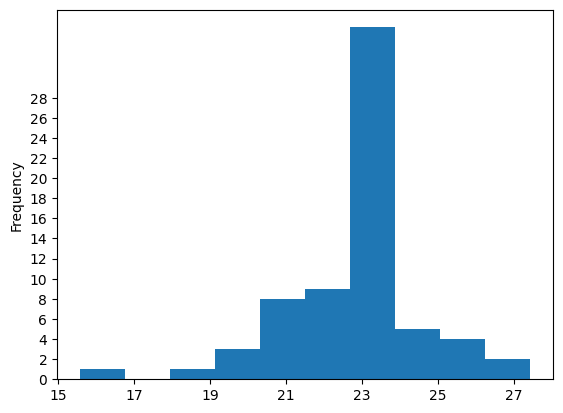

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

def stats(df):
    print(f"mean: {df['detector std'].mean()}, median: {df['detector std'].median()}, ", end='')
    print(f"min: {df['detector std'].min()}, max: {df['detector std'].max()}")

def create_df(std):
    df = pd.read_json(f"../analysis/noisy{std}.json")
    df = df.sort_values("name")
    df = df.reset_index(drop=True)
    return df

def extreme_values(df, minimum = None, maximum = None):
    if minimum is None:
        minimum = df['detector std'].min()
    if maximum is None:
        maximum = df['detector std'].max()
    mask_min = df['detector std'] <= minimum
    mask_max = df['detector std'] >= maximum
    print(df[mask_min | mask_max])

def detector_hist(df):
    df['detector std'].plot.hist()
    plt.xticks(np.arange(int(df['detector std'].min()), df['detector std'].max()+1, 2))
    plt.yticks(np.arange(0, 30, 2))
    plt.show()

def detector_plot(df):
    df.plot(x='name', y='detector std')
    plt.show()

df35 = create_df(35)
df50 = create_df(50)

stats(df35)
detector_hist(df35)

## Blur

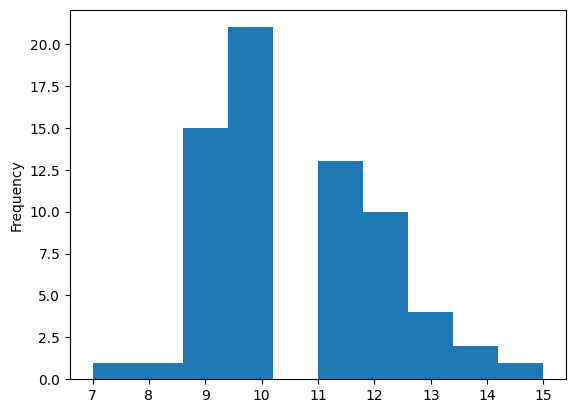

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

def std_stats(df, std):
    mask = df["std"]==std
    tmp = df[mask].copy()
    max_mask = tmp['b'] >= tmp['b'].max()
    min_mask = tmp['b'] <= tmp['b'].min()
    print(f"for std={std}:", tmp[max_mask | min_mask])

def create_df(std):
    df = pd.read_json("../analysis/blur.json")
    df = df.sort_values("name")
    df = df.reset_index(drop=True)
    mask = df['std'] == std
    df_std = df[mask]
    return df_std

df = pd.read_json("../analysis/blur.json")
df = df.sort_values("name")
df = df.reset_index(drop=True)

std = 2
df2 = create_df(std)
df2['b'].plot.hist()
plt.show()

## Salt and paper

mean: 33.4891556376479, median: 33.6058010091557, min: 30.87676127774033, max: 40.30078337183657
         name    s  detector s  detector g
164  0032.png  0.1   40.300783    4.447739


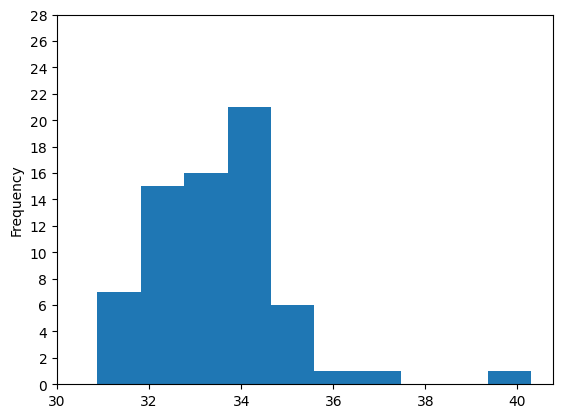

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

def stats(df, type = 's'):
    print(f"mean: {df[f'detector {type}'].mean()}, median: {df[f'detector {type}'].median()}, ", end='')
    print(f"min: {df[f'detector {type}'].min()}, max: {df[f'detector {type}'].max()}")

def create_df(p):
    df = pd.read_json("../analysis/snp.json")
    df = df.sort_values('name')
    df = df.reset_index(drop=True)
    mask = df['s'] == p
    ret = df[mask]
    return ret

def extreme_values(df, minimum = None, maximum = None, type = 's'):
    if minimum is None:
        minimum = df[f'detector {type}'].min()
    if maximum is None:
        maximum = df[f'detector {type}'].max()
    max_mask = df[f'detector {type}'] >= maximum
    min_mask = df[f'detector {type}'] <= minimum
    print(df[max_mask | min_mask])

def detector_hist(df, type='s'):
    df[f'detector {type}'].plot.hist()
    plt.xticks(np.arange(int(df[f'detector {type}'].min()), df[f'detector {type}'].max()+1, 2))
    plt.yticks(np.arange(0, 30, 2))
    plt.show()

def detector_plot(df):
    df.plot(x='name', y='detector s')
    plt.show()

p = 0.1
df = create_df(p)
stats(df)
extreme_values(df, 4, None)

detector_hist(df)

## Original

mean: 3.368508349446689, median: 2.223869562149048, min: 0.7412898540496821, max: 13.343217849731445


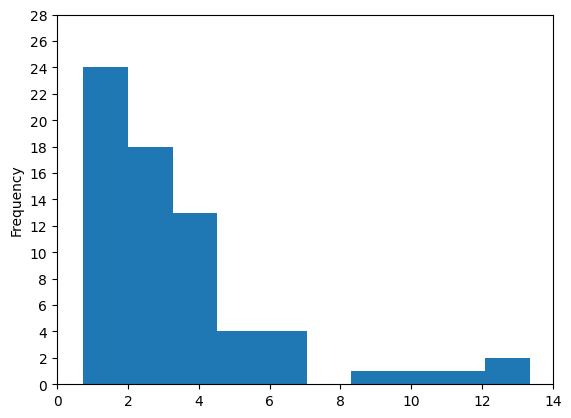

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

def stats(df, type = 's'):
    print(f"mean: {df[f'detector {type}'].mean()}, median: {df[f'detector {type}'].median()}, ", end='')
    print(f"min: {df[f'detector {type}'].min()}, max: {df[f'detector {type}'].max()}")

def create_df():
    df = pd.read_json("../analysis/src.json")
    df = df.sort_values('name')
    df = df.reset_index(drop=True)
    return df

def extreme_values(df, minimum = None, maximum = None, type = 's'):
    if minimum is None:
        minimum = df[f'detector {type}'].min()
    if maximum is None:
        maximum = df[f'detector {type}'].max()
    max_mask = df[f'detector {type}'] >= maximum
    min_mask = df[f'detector {type}'] <= minimum
    print(df[max_mask | min_mask])

def detector_hist(df, type='s'):
    df[f'detector {type}'].plot.hist()
    plt.xticks(np.arange(int(df[f'detector {type}'].min()), df[f'detector {type}'].max()+1, 2))
    plt.yticks(np.arange(0, 30, 2))
    plt.show()

def detector_plot(df):
    df.plot(x='name', y='detector s')
    plt.show()

df = create_df()
stats(df, "g")
detector_hist(df, "g")
